In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')
from permetrics.regression import RegressionMetric

In [3]:
from salishsea_tools import evaltools as et

In [4]:
dft = pd.read_excel('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/ammonia_PS.xlsx',parse_dates=['Collect DateTime'],index_col=False)

locs = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/eval/Water_Quality_Monitoring_Dashboard_-_Monitoring_Sites.csv')
dft = dft.merge(locs[['Locator', 'Latitude', 'Longitude']],on='Locator',how='left')

dft['Value'] = dft['Value'].astype(float)
dft['Collect DateTime'] = dft['Collect DateTime'].astype('datetime64[ns]')
dft = dft[dft['Value']>0]
dft = dft[dft['Depth (m)']>0].reset_index(drop=True)

dft = dft.rename(columns={"Latitude": "Lat", "Longitude": "Lon",'Collect DateTime':'dtUTC','Depth (m)':'Z','Value':'Ammonia'})[['Lat', 'Lon', 'dtUTC', 'Z','Ammonia']]
# df['dtUTC'] = df['dtUTC'].dt.tz_localize(None)
dft = dft[dft['Lat']>0].reset_index(drop=True) #drop non registered stations

In [5]:
filemap={'ammonium':'biol_T'}

fdict={'biol_T':1}
path = f'/data/jvalenti/results2/results2/'
mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

start_date = dt.datetime(2023,1,1) 
end_date = dt.datetime(2023,12,31) 

In [6]:
# data=et.matchData(dft,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# data.to_csv('NH4_2023_SHEM.csv')

In [7]:
# path = '/results2/SalishSea/nowcast-green.202111'

# data=et.matchData(dft,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('NH4_2023_202111.csv')

# path = '/ocean/atall/MOAD/Model/202410b/oxygen/'
# fdict={'biol_T':24}

# data=et.matchData(dft,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('NH4_2023_202410.csv')

In [8]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()
    evaluator = RegressionMetric(np.array(obs), np.array(predicted))
    WI = evaluator.willmott_index()
    cor = np.corrcoef(obs, predicted)[0, 1]
    print(f"RMSE: {rmse_val}, Bias: {bias}, Willmott Index: {WI}, N: {len(obs)},Nmod: {len(predicted)}, Correlation: {cor}")
    return rmse_val, bias,WI,len(obs)

In [9]:
# #Combine all versions in single file
# data= pd.read_csv('NH4_2023_SHEM.csv')
# data = data.rename(columns={'mod_ammonium':'SHEM_NH4'})
# data2= pd.read_csv('NH4_2023_202111.csv')
# data3= pd.read_csv('NH4_2023_202410.csv')

# data['v202111_NH4']=data2['mod_ammonium']
# data['v202410_NH4']=data3['mod_ammonium']


# data.to_csv('NH4_2023_all.csv')

In [12]:
data= pd.read_csv('NH4_2023-25_all.csv')

RMSE: 2.565792762321311, Bias: -1.7015362373018974, Willmott Index: 0.40223761412533365, N: 2898,Nmod: 2898, Correlation: -0.0235633989300924
RMSE: 1.7958103073757978, Bias: 0.11130327347029745, Willmott Index: 0.4515228040998339, N: 2898,Nmod: 2898, Correlation: 0.3557493767050111
RMSE: 2.8634333951440687, Bias: 2.030073993838822, Willmott Index: 0.47003381598893446, N: 2898,Nmod: 2898, Correlation: 0.25373331799284954


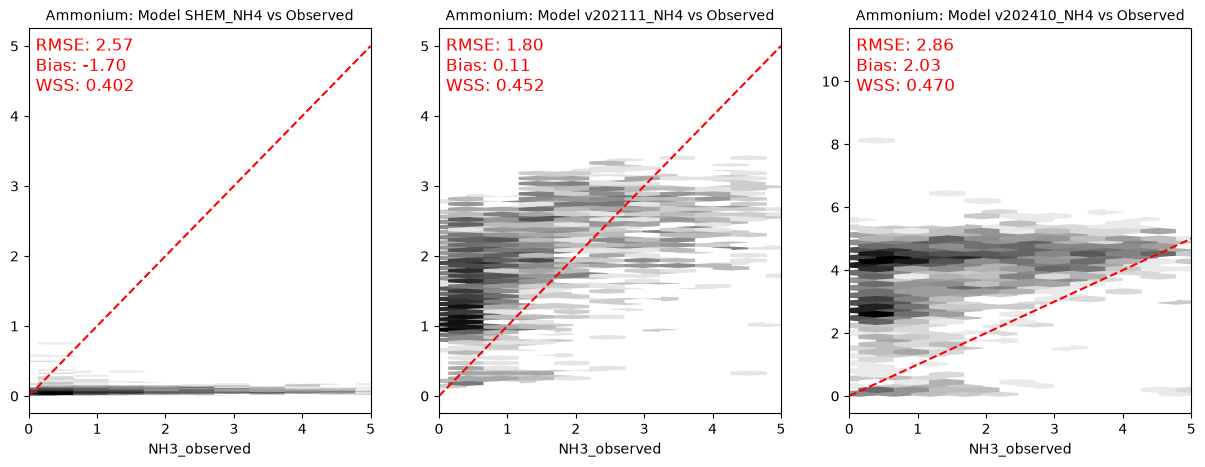

In [13]:
import matplotlib

def plot_o2(ax,data,name = "SHEM"):
    model = np.array(data[name])
    obs = np.array(data['Ammonia'])*71.39
    mask_N = (obs > 0) & (~np.isnan(model))
    rmse, bias, WI,N = calculate_rmse_bias(obs[mask_N], model[mask_N])
    #ax.scatter(obs[mask_N], model[mask_N],color='grey')
    ax.hexbin(obs[mask_N], model[mask_N],gridsize=80, norm=matplotlib.colors.LogNorm(),cmap='Greys')
    ax.set_xlabel('NH3_observed')
    ax.set_title(f'Ammonium: Model {name} vs Observed')

    ax.plot(np.linspace(0, 5),np.linspace(0, 5),'r--')
    ax.text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=ax.transAxes,color='red')
    ax.set_xlim(0,5)

fig,axs = plt.subplots(1,3,figsize=(15,5))
plot_o2(axs[0],data,'SHEM_NH4')
plot_o2(axs[1],data,'v202111_NH4')
plot_o2(axs[2],data,'v202410_NH4')

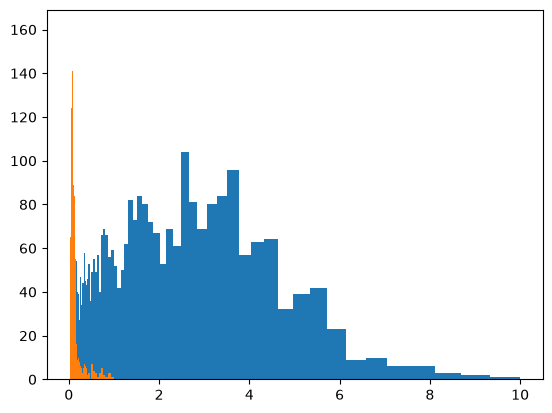

In [14]:
a = plt.hist(data.Ammonia* 71.39,bins = np.logspace(-2,1,100))
a = plt.hist(data.SHEM_NH4,bins = np.logspace(-2,1,100))
#a = plt.hist(data.v202111_NH4,bins = np.logspace(-2,1,100))
#a = plt.hist(data.v202410_NH4,bins = np.logspace(-2,1,100))